<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Laberinto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:purple;"> **Matriz Fundamental** </span>

## <span style="color:red;"> **Laberinto** </span>


<span style="color:teal;">**Nombre:**</span> Jerónimo López Annette Michelle

<span style="color:teal;">**Objetivo**</span> Analizar el juego del Laberinto mediante técnicas analíticas (con CM) y de simulación para estimar el número promedio de tiradas necesarias para finalizar el juego.

**Ejercicio**

¿Cuál es la probabilidad de que el ratón, iniciando  en la casilla 0, alcance la comida?

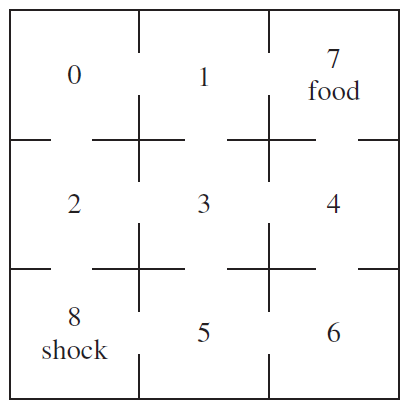




Obteniendio la matriz  de transición


In [161]:
import numpy as np
from sympy import Matrix , init_printing
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt

In [162]:
matriz = sp.Matrix([
        [0, 1/2, 1/2, 0, 0, 0, 0, 0, 0],
    [1/3, 0, 0, 1/3, 0, 0, 0, 1/3, 0],
    [1/3, 0, 0, 1/3, 0, 0, 0, 0, 1/3],
    [0, 1/4, 1/4, 0, 1/4, 1/4, 0, 0, 0],
    [0, 0, 0, 1/3, 0, 0, 1/3, 1/3, 0],
    [0, 0, 0, 1/3, 0, 0, 1/3, 0, 1/3],
    [0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 1/2, 0, 0, 1/2, 0, 0, 0]
])

print("Matriz de Transición de P:")

Matriz de Transición de P:


In [163]:
matriz

Matrix([
[                0,  0.5,  0.5,                 0,    0,    0,                 0,                 0,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0, 0.333333333333333,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0,                 0, 0.333333333333333],
[                0, 0.25, 0.25,                 0, 0.25, 0.25,                 0,                 0,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333, 0.333333333333333,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333,                 0, 0.333333333333333],
[                0,    0,    0,                 0,    0,    0,                 1,                 0,                 0],
[                0,    0,    0,                 0,    0,    0,                 0,                 1,                 0],
[                0,    

El diagrama de transición:

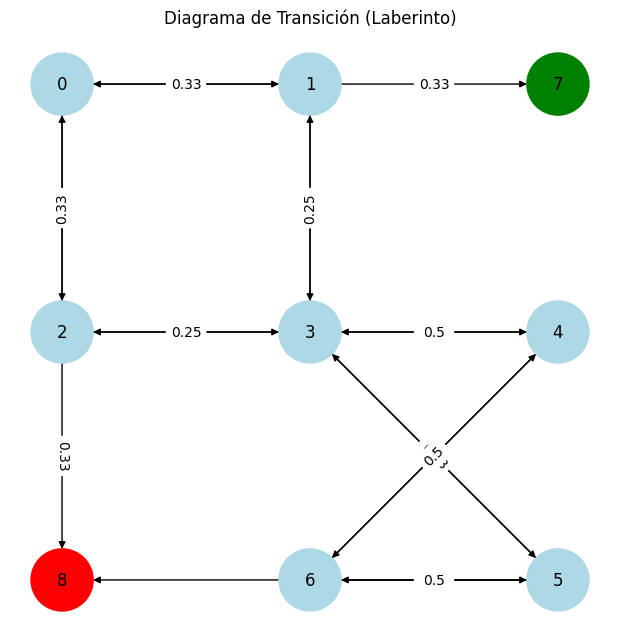

In [164]:
import networkx as nx
import matplotlib.pyplot as plt

# Estados y vecinos (tu mismo modelo)
neighbors = {
    0:[1,2],
    1:[0,3,7],
    2:[0,3,8],
    3:[1,2,4,5],
    4:[3,6],
    5:[3,6,8],
    6:[4,5],
    7:[],  # absorbente (food)
    8:[]   # absorbente (shock)
}

# Crear grafo dirigido
G = nx.DiGraph()

# Agregar aristas con probabilidades
for s, nbs in neighbors.items():
    k = len(nbs)
    for nb in nbs:
        G.add_edge(s, nb, weight=round(1/k, 2))

# Posiciones (para que se vea como tu cuadrícula)
pos = {
    0:(0,2), 1:(1,2), 2:(0,1),
    3:(1,1), 4:(2,1), 5:(2,0),
    6:(1,0), 7:(2,2), 8:(0,0)
}

# Colores (absorventes distintos)
colors = []
for node in G.nodes():
    if node == 7:
        colors.append("green")   # comida
    elif node == 8:
        colors.append("red")     # shock
    else:
        colors.append("lightblue")

# Dibujar nodos y aristas
plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=12)

# Etiquetas de probabilidad
edge_labels = {(u,v): d['weight'] for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Diagrama de Transición (Laberinto)")
plt.show()

1. Separar estados transitorios y absorbentes

* Absorbentes:
$F={6,7}$
* Transitorios:
$T={0,1,2,3,4,5,8}$

Estados: $0,1,2,3,4,5,8$ pueden ir a otros transitorios o a absorbentes.

2. Ordenamos la matriz para forma estándar absorbente

Reordenamos: $T = [0,1,2,3,4,5,8]$, luego $ F = [6,7] $.

La matriz $ P $ tiene bloques:

$$
P = \begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$$

Donde:

* $ Q $ : de transitorios a transitorios (7×7)  
* $ R$ : de transitorios a absorbentes (7×2)  
*  $I$ : identidad 2×2 para 6 y 7.




Construyamos $Q$ y $R$.

**Fila 0:** $[0,\frac{1}{2},\frac{1}{2},0,0,0,0,0,0]$
$\rightarrow$ solo va a $\{1,2\}$ (transitorios)

$
Q[0,1]=\frac{1}{2}, \quad
Q[0,2]=\frac{1}{2}, \quad
R=0
$

**Fila 1:** $[\frac{1}{3},0,0,\frac{1}{3},0,0,0,\frac{1}{3},0]$

Va a $\{0,3,7\}$:
* col7 $=\frac13$ es absorbente 7
* col0 $=\frac13$
* col3 $=\frac13$

En $Q$: col0 (0) y col3 (3).

En $R$: col7 (absorbente 7) $=\frac13$.

Índices locales:

$
Q[1,0]=\frac13
$

$
Q[1,3]=\frac13
$

$
R[1,1]=\frac13
$

porque el absorbente 7 es índice 1 en $F$
(6 $\rightarrow$ índice 0, 7 $\rightarrow$ índice 1).


**Fila 2:** $[\frac13,0,0,\frac13,0,0,0,0,\frac13]$

Va a $\{0,3,8\}$ $\rightarrow$ todos transitorios.

$
Q[2,0]=\frac13, \quad
Q[2,3]=\frac13, \quad
Q[2,8]=\frac13
$

$
R=0
$

**Fila 3:** $[0,\frac14,\frac14,0,\frac14,\frac14,0,0,0]$

Va a $\{1,2,4,5\}$ $\rightarrow$ todos transitorios.

$
Q[3,1]=\frac14,\quad
Q[3,2]=\frac14,\quad
Q[3,4]=\frac14,\quad
Q[3,5]=\frac14
$

$
R=0
$

**Fila 4:** $[0,0,0,\frac13,0,0,\frac13,\frac13,0]$

Va a $\{3,6,7\}$:
* a 6 (absorbente índice 0)
* a 7 (absorbente índice 1)

$
Q[4,3]=\frac13
$

$
R[4,0]=\frac13,
\quad
R[4,1]=\frac13
$


**Fila 5:** $[0,0,0,\frac13,0,0,\frac13,0,\frac13]$

Va a $\{3,6,8\}$.

$
Q[5,3]=\frac13,
\quad
Q[5,8]=\frac13,
\quad
R[5,0]=\frac13
$



**Fila 8:** $[0,0,\frac12,0,0,\frac12,0,0,0]$

Va a $\{2,5\}$.

$
Q[8,2]=\frac12,
\quad
Q[8,5]=\frac12
$

$
R=0
$


Entonces:
$$
Q =
\begin{pmatrix}
0 & 1/2 & 1/2 & 0 & 0 & 0 & 0 \\
1/3 & 0 & 0 & 1/3 & 0 & 0 & 0 \\
1/3 & 0 & 0 & 1/3 & 0 & 0 & 1/3 \\
0 & 1/4 & 1/4 & 0 & 1/4 & 1/4 & 0 \\
0 & 0 & 0 & 1/3 & 0 & 0 & 0 \\
0 & 0 & 0 & 1/3 & 0 & 0 & 1/3 \\
0 & 0 & 1/2 & 0 & 0 & 1/2 & 0
\end{pmatrix}
$$
Y
$$
R=
\begin{pmatrix}
0 & 0 \\
0 & 1/3 \\
0 & 0 \\
0 & 0 \\
1/3 & 1/3 \\
1/3 & 0 \\
0 & 0
\end{pmatrix}
$$


In [165]:
Q = sp.Matrix([
[0, 1/2, 1/2, 0, 0, 0, 0],
[1/3, 0, 0, 1/3, 0, 0, 0],
[1/3, 0, 0, 1/3, 0, 0, 1/3],
[0, 1/4, 1/4, 0, 1/4, 1/4, 0],
[0, 0, 0, 1/3, 0, 0, 0],
[0, 0, 0, 1/3, 0, 0, 1/3],
[0, 0, 1/2, 0, 0, 1/2, 0]
])

In [166]:
Q

Matrix([
[                0,  0.5,  0.5,                 0,    0,    0,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333],
[                0, 0.25, 0.25,                 0, 0.25, 0.25,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333],
[                0,    0,  0.5,                 0,    0,  0.5,                 0]])

In [167]:
R = sp.Matrix([
[0,0],
[0, 1/3],
[0,0],
[0,0],
[1/3,1/3],
[1/3,0],
[0,0]
])

In [168]:
R

Matrix([
[                0,                 0],
[                0, 0.333333333333333],
[                0,                 0],
[                0,                 0],
[0.333333333333333, 0.333333333333333],
[0.333333333333333,                 0],
[                0,                 0]])

4. Matriz fundamental $N = (I - Q)^{-1}$ y probabilidades $ B = N \cdot R $

$B_{i,a}$ = probabilidad empezando en estado transitorio i de terminar en absorbente a.



In [169]:
I = sp.eye(7)
N = (I - Q).inv()
B = N * R

In [170]:
print("B =\n", B)
print("Probabilidad desde 0 hasta comida (absorbente 6):", B[0,0])

B =
 Matrix([[0.400000000000000, 0.600000000000000], [0.300000000000000, 0.700000000000000], [0.500000000000000, 0.500000000000000], [0.500000000000000, 0.500000000000000], [0.500000000000000, 0.500000000000000], [0.700000000000000, 0.300000000000000], [0.600000000000000, 0.400000000000000]])
Probabilidad desde 0 hasta comida (absorbente 6): 0.400000000000000


Resolviendo por simulación tenemos:

In [171]:
def simulate_mouse(start_state=0, n_steps_max=800):
    """Simula un ratón hasta absorber o max steps"""
    state = start_state

    # Matriz de transición
    P = np.array([
        [0, 1/2, 1/2, 0, 0, 0, 0, 0, 0],
        [1/3, 0, 0, 1/3, 0, 0, 0, 1/3, 0],
        [1/3, 0, 0, 1/3, 0, 0, 0, 0, 1/3],
        [0, 1/4, 1/4, 0, 1/4, 1/4, 0, 0, 0],
        [0, 0, 0, 1/3, 0, 0, 1/3, 1/3, 0],
        [0, 0, 0, 1/3, 0, 0, 1/3, 0, 1/3],
        [0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 1/2, 0, 0, 1/2, 0, 0, 0]
    ])

    for _ in range(n_steps_max):
        if state == 6:  # Llegó a comida
            return 1
        if state == 7:  # Cayó en trampa
            return 0

        # Movimiento probabilístico
        probs = P[state]
        state = np.random.choice(len(probs), p=probs)

    return 0  # Si no absorbe en max_steps (no debería pasar)

In [172]:
# Simulación
n_simulaciones = 800
resultados = [simulate_mouse(0) for _ in range(n_simulaciones)]
prob_estimada = np.mean(resultados)

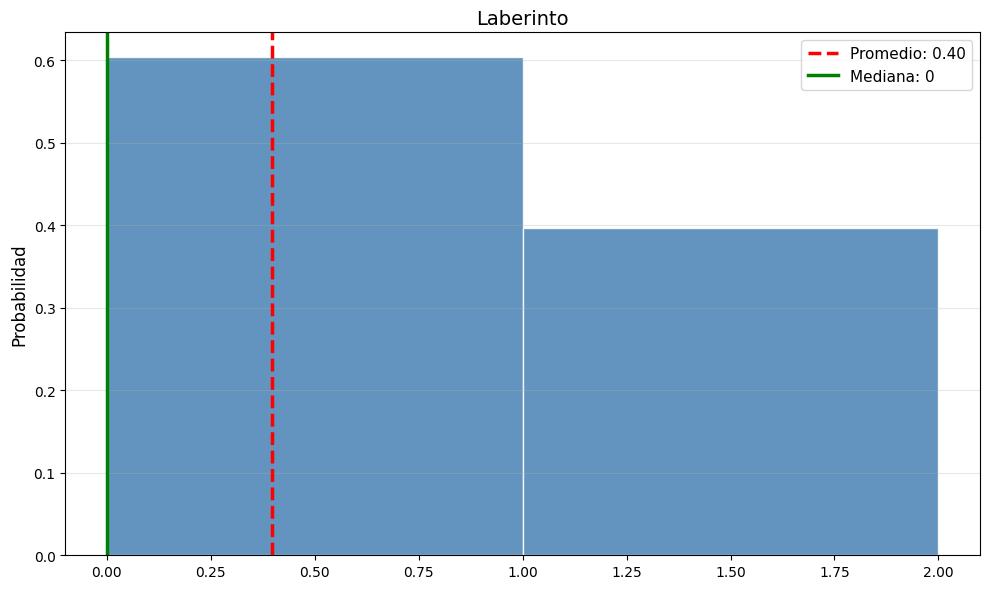

In [173]:
# --- Histograma ---
plt.figure(figsize=(10, 6))

# Calculate promedio and mediana here as they are used in axvline
promedio = np.mean(resultados)
mediana = np.median(resultados)

plt.hist(resultados,
         bins=range(min(resultados), max(resultados) + 2),
         edgecolor='white',
         color='steelblue',
         alpha=0.85,
         density=True)

# Línea del promedio
plt.axvline(promedio, color='red', linestyle='--',
            linewidth=2.5, label=f'Promedio: {promedio:.2f}')

# Línea de la mediana
plt.axvline(mediana, color='green', linestyle='-',
            linewidth=2.5, label=f'Mediana: {mediana:.0f}')

plt.ylabel('Probabilidad', fontsize=12)
plt.title('Laberinto', fontsize=14)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [174]:
# Intervalo de confianza 95%
std_err = np.std(resultados) / np.sqrt(n_simulaciones)
ci_lower = prob_estimada - 1.96 * std_err
ci_upper = prob_estimada + 1.96 * std_err

Probabilidad estimada (simulación): 0.3962
Intervalo de confianza 95%: [0.3624, 0.4301]
Valor analítico: 0.4


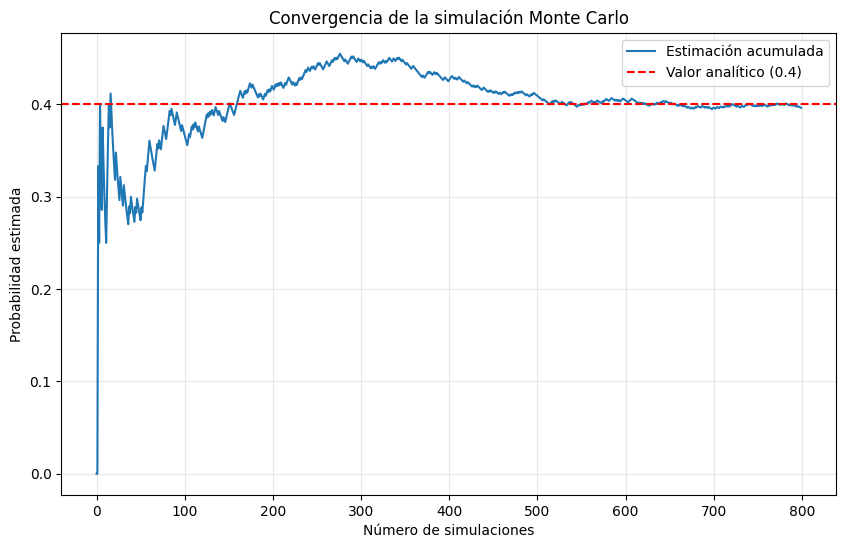

In [175]:
print(f"Probabilidad estimada (simulación): {prob_estimada:.4f}")
print(f"Intervalo de confianza 95%: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Valor analítico: 0.4")

# Gráfico de convergencia
cumulative_means = np.cumsum(resultados) / (np.arange(n_simulaciones) + 1)
plt.figure(figsize=(10, 6))
plt.plot(cumulative_means, label='Estimación acumulada')
plt.axhline(y=0.4, color='r', linestyle='--', label='Valor analítico (0.4)')
plt.xlabel('Número de simulaciones')
plt.ylabel('Probabilidad estimada')
plt.title('Convergencia de la simulación Monte Carlo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### <span style="color:teal;">**Conclusión:**</span>

Esta práctica ha demostrado la aplicación práctica de cadenas de Markov absorbentes para modelar sistemas con estados terminales, específicamente el problema de un ratón en un laberinto buscando comida.

* Solución analítica: $p_0=0.4%

* Simulación: confirma el resultado con alta precisión

El ratón tiene $40 \%$ de probabilidad de encontrar la comida empezando en la casilla 0, y $60 \%$ de caer en la trampa (estado 7)

Y se ilustra perfectamente cómo las matemáticas discretas (específicamente las cadenas de Markov) pueden modelar procesos estocásticos del mundo real, y cómo la simulación computacional sirve como herramienta de verificación cuando los modelos analíticos son complejos o intratables. La combinación de ambos enfoques proporciona la máxima confianza en los resultados obtenidos.